# 1D Lineare Kalman-Filter Lokalisierung

Dieses Notebook demonstriert die Funktionsweise eines **1D linearen Kalman-Filters** zur Zustandsschätzung (Position, Geschwindigkeit und Beschleunigung) eines sich bewegenden Objekts basierend auf verrauschten Messungen.

Das Notebook nutzt und importiert das Python-Skript `01_kalman_localization_1d_linear.py`.

---

## 1. Import der benötigten Bibliotheken und des Skripts

Zunächst importieren wir `numpy`, `matplotlib.pyplot` sowie die Funktionen aus `01_kalman_localization_1d_linear.py`.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Pfad zum lokalen Verzeichnis hinzufügen, um das Python-Skript zu importieren
sys.path.append('.')
import importlib
kalman_module = importlib.import_module('01_kalman_localization_1d_linear')

print("Modul 01_kalman_localization_1d_linear erfolgreich importiert!")

Modul 01_kalman_localization_1d_linear erfolgreich importiert!


## 2. Konfiguration & Filter-Einstellungen

Sie können hier die Parameter des Kalman-Filters und der Simulation anpassen:

- **`meas`**: Messkonfiguration. Mögliche Werte:
  - `'p'`: Nur Position wird gemessen
  - `'v'`: Nur Geschwindigkeit wird gemessen
  - `'a'`: Nur Beschleunigung wird gemessen
  - `'p_v'`: Position und Geschwindigkeit werden gemessen
  - `'p_a'`: Position und Beschleunigung werden gemessen
  - `'p_v_a'`: Position, Geschwindigkeit und Beschleunigung werden gemessen
- **`num_y`**: Anzahl der Zeitschritte (z. B. 80)
- **`sigma_scale`**: Vielfaches der Standardabweichung $\sigma$ für die Darstellung der Schätzunsicherheit (z. B. 1.0 oder 2.0 für $1\sigma$ bzw. $2\sigma$ Konfidenzintervall).

In [2]:
# Einstellung der gemessenen Größen: 'p', 'v', 'a', 'p_v', 'p_a' oder 'p_v_a'
meas = 'p_a'

# Anzahl der Simulationsschritte
num_y = 80

# Unsicherheitsband in Vielfachen der Standardabweichung (1 = 1-Sigma, 2 = 2-Sigma)
sigma_scale = 2.0

## 3. Ausführung der Kalman-Filter Lokalisierung

Wir führen die Kalman-Filter Schätzung mit den gewählten Einstellungen aus und berechnen zusätzlich den exakten Verlauf von Ground Truth Geschwindigkeit und Beschleunigung für die Auswertung.

In [3]:
# Kalman-Filter Simulation ausführen
xs, b_true, cov, y, Rs, num_y = kalman_module.run_kalman(num_y=num_y, meas=meas)

# Zeitschritte und Abtastrate dt aus dem System abrufen
_, _, _, _, _, _, _, _, _, dt = kalman_module.init_system(num_y=num_y, meas=meas)
time_steps = np.arange(num_y) * dt

# Erzeugung der Ground Truth für Beschleunigung und Geschwindigkeit zur Visualisierung
acc_gt = kalman_module.generate_acc(num_y)
vel_gt = np.zeros(num_y)
pos_gt = np.zeros(num_y)
curr_pos, curr_vel = 0.5, 0.0

# Rekonstruktion der Ground Truth Trajektorie ohne Prozessrauschen
for i in range(num_y):
    curr_pos += curr_vel * dt + 0.5 * acc_gt[i] * dt**2
    curr_vel += acc_gt[i] * dt
    pos_gt[i] = curr_pos
    vel_gt[i] = curr_vel

# Extraktion der Schätzwerte und Varianzen
p_estim = xs[:, 0, 0]
v_estim = xs[:, 1, 0]
a_estim = xs[:, 2, 0]

p_std = np.sqrt(cov[:, 0, 0])
v_std = np.sqrt(cov[:, 1, 1])
a_std = np.sqrt(cov[:, 2, 2])

estimation error: 0.21076537387901417
b_estim: [[0.47970507]
 [0.5002866 ]
 [0.80432704]
 [0.70438985]
 [0.30442112]
 [0.30626619]
 [0.2763573 ]
 [0.58561641]
 [0.84405237]
 [0.94352213]
 [1.42843147]
 [1.66176051]
 [1.4831511 ]
 [1.71785599]
 [1.78945068]
 [1.86233811]
 [1.79638802]
 [1.87559614]
 [2.10912043]
 [2.27780477]
 [2.37220439]
 [2.57621155]
 [2.77587774]
 [2.92087787]
 [3.11695919]
 [3.2233884 ]
 [3.17262819]
 [3.38430984]
 [3.45378069]
 [3.52384369]
 [3.69317151]
 [3.74903648]
 [3.87406533]
 [3.87447404]
 [3.93056544]
 [4.1835705 ]
 [4.26204562]
 [4.40999022]
 [4.54072481]
 [4.73780316]
 [4.80053512]
 [4.97969557]
 [5.0495817 ]
 [5.05639765]
 [5.1943304 ]
 [5.25562655]
 [5.2977724 ]
 [5.32062624]
 [5.49176951]
 [5.66064113]
 [5.80239403]
 [5.93784166]
 [6.07848037]
 [6.14536359]
 [6.23021048]
 [6.4412142 ]
 [6.5034272 ]
 [6.63090749]
 [6.81536849]
 [6.96060728]
 [6.96793863]
 [7.04192415]
 [7.09880173]
 [7.14329278]
 [7.11757575]
 [7.13206237]
 [7.12300045]
 [7.28744952]
 

## 4. Visualisierung: Geschätzte Zustände & Schätzunsicherheit

Nachfolgend werden Position, Geschwindigkeit und Beschleunigung über der Zeit dargestellt. Die Schätzunsicherheit der jeweiligen Zustandsvariable wird als **schraffierte Fläche** ($\pm \sigma \cdot \text{sigma\_scale}$) um den geschätzten Verlauf visualisiert.

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_49999/4170062160.py:13: SyntaxWarning: invalid escape sequence '\p'
  label=f'Schätzunsicherheit (\pm {sigma_scale:.0f}\sigma)'
/tmp/ipykernel_49999/4170062160.py:13: SyntaxWarning: invalid escape sequence '\s'
  label=f'Schätzunsicherheit (\pm {sigma_scale:.0f}\sigma)'
/tmp/ipykernel_49999/4170062160.py:34: SyntaxWarning: invalid escape sequence '\p'
  label=f'Schätzuns

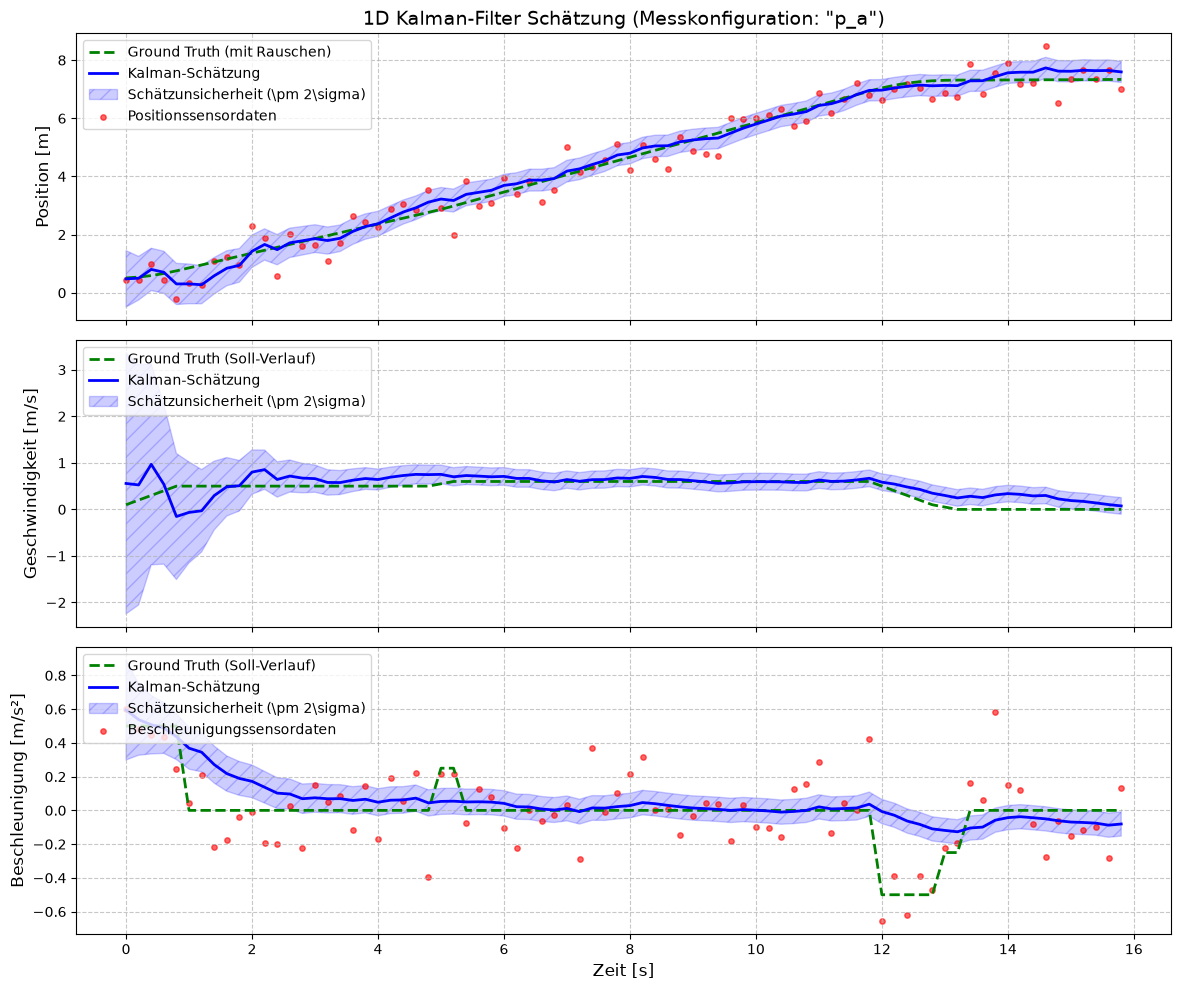

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot: Position
axs[0].plot(time_steps, b_true, 'g--', label='Ground Truth (mit Rauschen)', linewidth=2)
axs[0].plot(time_steps, p_estim, 'b-', label='Kalman-Schätzung', linewidth=2)
axs[0].fill_between(
    time_steps,
    p_estim - sigma_scale * p_std,
    p_estim + sigma_scale * p_std,
    color='blue',
    alpha=0.2,
    hatch='//',
    label=f'Schätzunsicherheit (\pm {sigma_scale:.0f}\sigma)'
)
if 'p' in meas:
    # Extraktion der Messungen für Position (erstes Element in y falls p enthalten)
    p_meas_idx = 0
    axs[0].scatter(time_steps, y[:, p_meas_idx, 0], color='red', s=15, alpha=0.6, label='Positionssensordaten')
axs[0].set_ylabel('Position [m]', fontsize=12)
axs[0].set_title(f'1D Kalman-Filter Schätzung (Messkonfiguration: "{meas}")', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].legend(loc='upper left')

# 2. Plot: Geschwindigkeit
axs[1].plot(time_steps, vel_gt, 'g--', label='Ground Truth (Soll-Verlauf)', linewidth=2)
axs[1].plot(time_steps, v_estim, 'b-', label='Kalman-Schätzung', linewidth=2)
axs[1].fill_between(
    time_steps,
    v_estim - sigma_scale * v_std,
    v_estim + sigma_scale * v_std,
    color='blue',
    alpha=0.2,
    hatch='//',
    label=f'Schätzunsicherheit (\pm {sigma_scale:.0f}\sigma)'
)
if 'v' in meas:
    v_meas_idx = 0 if meas == 'v' else (1 if meas in ['p_v', 'v_a'] else 1)
    axs[1].scatter(time_steps, y[:, v_meas_idx, 0], color='red', s=15, alpha=0.6, label='Geschwindigkeitssensordaten')
axs[1].set_ylabel('Geschwindigkeit [m/s]', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].legend(loc='upper left')

# 3. Plot: Beschleunigung
axs[2].plot(time_steps, acc_gt, 'g--', label='Ground Truth (Soll-Verlauf)', linewidth=2)
axs[2].plot(time_steps, a_estim, 'b-', label='Kalman-Schätzung', linewidth=2)
axs[2].fill_between(
    time_steps,
    a_estim - sigma_scale * a_std,
    a_estim + sigma_scale * a_std,
    color='blue',
    alpha=0.2,
    hatch='//',
    label=f'Schätzunsicherheit (\pm {sigma_scale:.0f}\sigma)'
)
if 'a' in meas:
    a_meas_idx = y.shape[1] - 1
    axs[2].scatter(time_steps, y[:, a_meas_idx, 0], color='red', s=15, alpha=0.6, label='Beschleunigungssensordaten')
axs[2].set_ylabel('Beschleunigung [m/s²]', fontsize=12)
axs[2].set_xlabel('Zeit [s]', fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.7)
axs[2].legend(loc='upper left')

plt.tight_layout()
plt.show()